In [1]:
! pip install torch==2.5.1 torchvision==0.20.1 torchaudio==2.5.1 xformers -U
! pip install accelerate datasets transformers
! pip install bitsandbytes
! pip install peft safetensors wandb

INFO: pip is looking at multiple versions of xformers to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 906.5/906.5 MB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.2/7.2 MB 45.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 62.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 93.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 73.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 50.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 12.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.4 

In [2]:
from huggingface_hub import notebook_login

notebook_login()

In [3]:
%%capture
!sudo apt -qq install git-lfs
!git config --global credential.helper store

Gradient Accumulation: technique that enables us to simulate large batch size without increasing memory usage
<li> ex we want train on batch size = 64 but memory constraints we can use batch_size = 16.
<li>With gradient accumulation, you can:

Use train_batch_size = 16

Set gradient_accumulation_steps = 4

That way, after every 4 mini-batches of size 16, gradients are averaged and a single update is done — as if you trained with a batch size of 16 * 4 = 64.

<li>Batch 1 (size=8): ➡️ Compute gradients ➡️ Store (don't update)
<li>Batch 2 (size=8): ➡️ Compute gradients ➡️ Add to previous ➡️ Average ➡️ ✅ Update weights


In [4]:
from dataclasses import dataclass

@dataclass
class TrainingConfig:
    image_size = 128
    train_batch_size = 16
    eval_batch_size = 16
    num_epochs = 50
    gradient_accumulation_steps=1 # technique that enables us to simulate large batch size without increasing memory usage
    learning_rate = 1e-4
    lr_warmup_steps = 500 # Gradually increases the learning rate over the first 500 steps for better stability
    save_image_epochs = 10
    save_model_epochs = 30
    mixed_precision = 'fp16' #Uses half-precision floating point (FP16) training for better speed and lower memory use (if supported by hardware).
    output_dir = 'ddpm-butterflies-128'

    push_to_hub = True
    hub_private_repo = False
    overwrite_output_dir = True
    seed = 0

config =  TrainingConfig()



In [5]:
from datasets import load_dataset

config.dataset_name = "huggan/smithsonian_butterflies_subset"
dataset = load_dataset(config.dataset_name,split='train')

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/609 [00:00<?, ?B/s]

Repo card metadata block was not found. Setting CardData to empty.


dataset_infos.json:   0%|          | 0.00/1.65k [00:00<?, ?B/s]

train-00000-of-00001.parquet:   0%|          | 0.00/237M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/1000 [00:00<?, ? examples/s]

In [6]:
dataset

Dataset({
    features: ['image_url', 'image_alt', 'id', 'name', 'scientific_name', 'gender', 'taxonomy', 'region', 'locality', 'date', 'usnm_no', 'guid', 'edan_url', 'source', 'stage', 'image', 'image_hash', 'sim_score'],
    num_rows: 1000
})

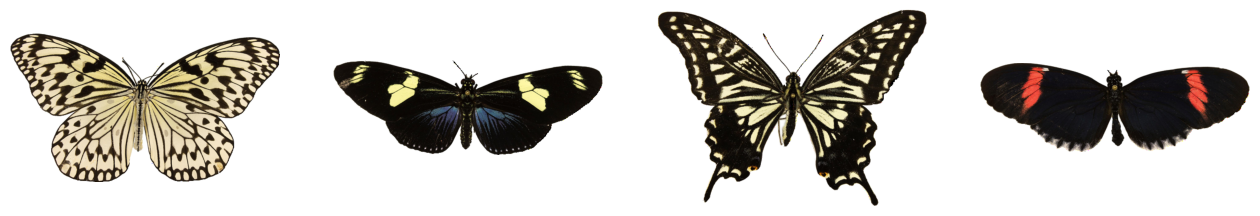

In [7]:
import matplotlib.pyplot as plt

fig,axs = plt.subplots(1,4,figsize=(16,4))

for i,image in enumerate(dataset[:4]['image']):
    axs[i].imshow(image)
    axs[i].set_axis_off()
fig.show()

In [8]:
from torchvision import transforms

preprocess = transforms.Compose([
    transforms.Resize((config.image_size,config.image_size)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize([0.5],[0.5])
])

In [9]:
def transform(examples):
    images = [preprocess(image.convert('RGB')) for image in examples['image']]
    return {'images':images}

dataset.set_transform(transform)

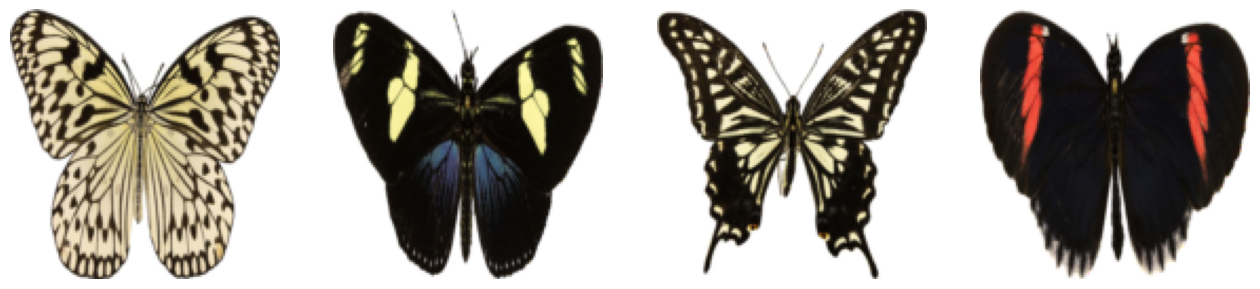

In [10]:
fig, axs = plt.subplots(1, 4, figsize=(16, 4))
for i, image in enumerate(dataset[:4]["images"]):
    axs[i].imshow(image.permute(1, 2, 0).numpy() / 2 + 0.5)
    axs[i].set_axis_off()
fig.show()

In [11]:
import torch

train_dataloader = torch.utils.data.DataLoader(dataset, batch_size=config.train_batch_size, shuffle=True)

In [12]:
from diffusers import UNet2DModel


model = UNet2DModel(
    sample_size = config.image_size,
    in_channels=3,
    out_channels=3,
    layers_per_block=2,
    block_out_channels=(128,128,256,256,512,512), # no of output channels for each unet blk
    down_block_types = (
        "DownBlock2D",  # a regular ResNet downsampling block
        "DownBlock2D",
        "DownBlock2D",
        "DownBlock2D",
        "AttnDownBlock2D",  # a ResNet downsampling block with spatial self-attention focuses on important object areas like face
        "DownBlock2D",),
    up_block_types = ("UpBlock2D",  # a regular ResNet upsampling block
        "AttnUpBlock2D",  # a ResNet upsampling block with spatial self-attention refine details
        "UpBlock2D",
        "UpBlock2D",
        "UpBlock2D",
        "UpBlock2D"  ))

In [13]:
sample_image = dataset[0]['images'].unsqueeze(0)
print('Input shape:',sample_image.shape)

Input shape: torch.Size([1, 3, 128, 128])


In [14]:
# .sample is the prediction of the noise
print('Output shape:', model(sample_image, timestep=0).sample.shape)

Output shape: torch.Size([1, 3, 128, 128])


In [15]:
model(sample_image,timestep=0).sample.shape

torch.Size([1, 3, 128, 128])

Now we can add noise to the image this is done by schedulers

In [16]:
from diffusers import DDPMScheduler

noise_scheduler = DDPMScheduler(num_train_timesteps=1000)

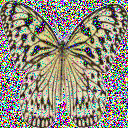

In [17]:
import torch
from PIL import Image

noise = torch.randn_like(sample_image)
timesteps = torch.LongTensor([50])
noisy_image = noise_scheduler.add_noise(sample_image,noise,timesteps)
Image.fromarray(((noisy_image.permute(0, 2, 3, 1) + 1.0) * 127.5).type(torch.uint8).numpy()[0])

In [18]:
from torch.nn import functional as F

noise_pred = model(noisy_image,timesteps).sample
loss = F.mse_loss(noise_pred,noise)
loss

tensor(1.1122, grad_fn=<MseLossBackward0>)

In [19]:
optimizer = torch.optim.AdamW(model.parameters(),lr=config.learning_rate)

In [20]:
from diffusers.optimization import get_cosine_schedule_with_warmup

lr_scheduler = get_cosine_schedule_with_warmup(
    optimizer=optimizer,
    num_warmup_steps=config.lr_warmup_steps,  # e.g. 500
    num_training_steps=(len(train_dataloader) * config.num_epochs)
)


In [21]:
from diffusers import DDPMPipeline
import os

import math

def make_grid(images, rows, cols):
    w, h = images[0].size
    grid = Image.new('RGB', size=(cols*w, rows*h))
    for i, image in enumerate(images):
        grid.paste(image, box=(i%cols*w, i//cols*h))
    return grid

def evaluate(config, epoch, pipeline):
    # Sample some images from random noise (this is the backward diffusion process).
    # The default pipeline output type is `List[PIL.Image]`
    images = pipeline(
        batch_size = config.eval_batch_size,
        generator=torch.manual_seed(config.seed),
    ).images

    # Make a grid out of the images
    image_grid = make_grid(images, rows=4, cols=4)

    # Save the images
    test_dir = os.path.join(config.output_dir, "samples")
    os.makedirs(test_dir, exist_ok=True)
    image_grid.save(f"{test_dir}/{epoch:04d}.png")

In [23]:
from accelerate import Accelerator
from accelerate.utils import ProjectConfiguration
from huggingface_hub import create_repo,upload_folder
from tqdm.auto import tqdm
from pathlib import Path
import os

def train_loop(config,model,noise_scheduler,optimizer,train_dataloader,lr_scheduler):
    logging_dir = os.path.join(config.output_dir,'logs')

    accelerator_project_config = ProjectConfiguration(project_dir=config.output_dir,logging_dir=logging_dir)

    accelerator = Accelerator(
        mixed_precision=config.mixed_precision,
        gradient_accumulation_steps=config.gradient_accumulation_steps,
        log_with="tensorboard",
        project_config=accelerator_project_config,
    )

    if accelerator.is_main_process:
        if config.push_to_hub:
            repo_id = create_repo(
                repo_id=Path(config.output_dir).name, exist_ok=True
            ).repo_id
        elif config.output_dir is not None:
            os.makedirs(config.output_dir, exist_ok=True)
        accelerator.init_trackers("train_example")

    model,optimizer,train_dataloader,lr_scheduler = accelerator.prepare(model,
                                                                        optimizer,
                                                                        train_dataloader,
                                                                        lr_scheduler)
    global_step = 0 # keeps track of total no of training steps taken across all epochs and batches

    for  epoch in range(config.num_epochs):
        progress_bar = tqdm(total=len(train_dataloader), disable=not accelerator.is_local_main_process)
        progress_bar.set_description(f'Epoch: {epoch}')

        for step,batch in enumerate(train_dataloader):
            # forward diffusion process
            clean_images = batch['images']
            noise = torch.randn_like(clean_images).to(clean_images.device)
            bs = clean_images.shape[0]

            timesteps = torch.randint(0,noise_scheduler.num_train_timesteps,(bs,),device=clean_images.device).long()
            noisy_images = noise_scheduler.add_noise(clean_images,noise,timesteps)

            with accelerator.accumulate(model): # handles gradient accumulation
                noise_pred = model(noisy_images,timesteps,return_dict=False)[0]
                # noise_pred = model(noisy_image,timesteps).sample
                # note the above model(noisy_image,timesteps).sample is the same as the one above
                # noise_pred = model(noisy_images,timesteps,return_dict=False)[0] faster we will get the tuple
                loss = F.mse_loss(noise_pred,noise)
                accelerator.backward(loss)
                accelerator.clip_grad_norm_(model.parameters(),1.0) # clips gradients of model params so overall norm wont exceed 1.0
                # essentially prevents gradients from getting too large, scales down all gradients proportionally if total norm exceeds 1.0
                optimizer.step()
                lr_scheduler.step()
                optimizer.zero_grad()

            progress_bar.update(1)
            logs = {"loss": loss.detach().item(), "lr": lr_scheduler.get_last_lr()[0], "step": global_step}
            progress_bar.set_postfix(**logs)
            accelerator.log(logs,step=global_step)
            global_step += 1

        # After each epoch you optionally sample some demo images with evaluate() and save the model
        if accelerator.is_main_process:
            pipeline = DDPMPipeline(unet=accelerator.unwrap_model(model), scheduler=noise_scheduler)

            if (epoch + 1) % config.save_image_epochs == 0 or epoch == config.num_epochs - 1:
                evaluate(config, epoch, pipeline)

            if (epoch + 1) % config.save_model_epochs == 0 or epoch == config.num_epochs - 1:
                if config.push_to_hub:
                    upload_folder(
                        repo_id=repo_id,
                        folder_path=config.output_dir,
                        commit_message=f"Epoch {epoch}",
                        ignore_patterns=["step_*", "epoch_*"],
                    )
                else:
                    pipeline.save_pretrained(config.output_dir)



In [24]:
from accelerate import notebook_launcher
args = (config, model, noise_scheduler, optimizer, train_dataloader, lr_scheduler)

notebook_launcher(train_loop, args, num_processes=1)

Launching training on one GPU.


  0%|          | 0/63 [00:00<?, ?it/s]

/usr/local/lib/python3.11/dist-packages/diffusers/configuration_utils.py:140: FutureWarning: Accessing config attribute `num_train_timesteps` directly via 'DDPMScheduler' object attribute is deprecated. Please access 'num_train_timesteps' over 'DDPMScheduler's config object instead, e.g. 'scheduler.config.num_train_timesteps'.
  deprecate("direct config name access", "1.0.0", deprecation_message, standard_warn=False)


  0%|          | 0/63 [00:00<?, ?it/s]

  0%|          | 0/63 [00:00<?, ?it/s]

...

  0%|          | 0/1000 [00:00<?, ?it/s]

0049.png:   0%|          | 0.00/511k [00:00<?, ?B/s]

0039.png:   0%|          | 0.00/508k [00:00<?, ?B/s]

events.out.tfevents.1744448495.973a217d7103.749.0:   0%|          | 0.00/400k [00:00<?, ?B/s]

Upload 3 LFS files:   0%|          | 0/3 [00:00<?, ?it/s]

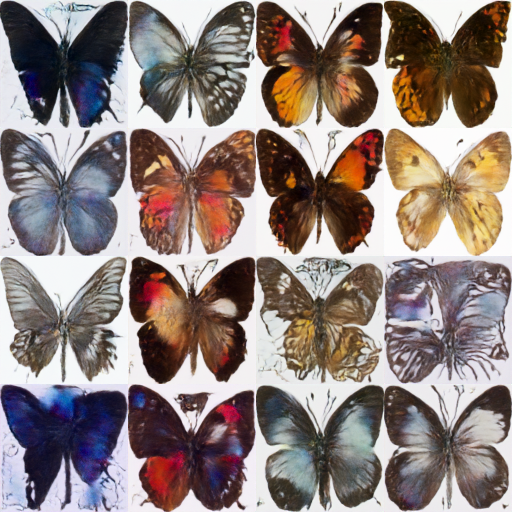

In [27]:
import glob

sample_images = sorted(glob.glob(f"{config.output_dir}/samples/*.png"))
Image.open(sample_images[-1])